# Feature Engineering


The following tutorial contains examples of Python code for feature engineering. 
You should refer to the "Feature Engineering" Lecture Note in Week 3.

Read the step-by-step instructions below carefully. 
To execute the code, click on the cell and press the SHIFT-ENTER keys simultaneously.

Recall the iris dataset has four features and one class:

- feature 1: sepal length in centimeters

- feature 2: sepal width in centimeters

- feature 3: petal length in centimeters

- feature 4: petal width in centimeters

- class (Setosa, Versicolour, Virginica) 

In this tutorial, you will learn how to:

- Conduct univariate feature selection algorithm.

- Conduct recursive feature elimination algorithm.

- Conduct PCA feature reduction algorithm.


## Summary of toolbox

1. Select the best K features based on univariate statistical tests: from sklearn.feature_selection import SelectKBest 
(link: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html)

2. feature selection criteria: from sklearn.feature_selection import f_classif,chi2,f_regression

4. Select the best K features based on model performance: from sklearn.feature_selection import SelectFromModel
Link: https://scikit-learn.org/stable/modules/feature_selection.html#select-from-model

4. models (to be continued): from sklearn.ensemble import ExtraTreesClassifier

5. recursive feature elimination from sklearn.feature_selection import RFE (https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html#sklearn.feature_selection.RFE)

6. PCA analysis from sklearn.decomposition import PCA (https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

### **1.0** *Univariate Feature Selection.* 
### Univariate feature selection works by selecting the best features based on univariate statistical tests. It can be seen as a preprocessing step to an estimator.

Source_link: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html 

**<font color='red'>Code:</font>** The following code identify the algorithm SelectKBest from sklearn library.

In [1]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif,chi2,f_regression
# f_classif: ANOVA F-value between label/feature for classification tasks.
# chi2: Chi-squared stats of non-negative features for classification tasks.
# f_regression F-value between label/feature for regression tasks.
import pandas as pd

### 1.1 Load your Raw Data

**<font color="red">Code:</font>**

In [2]:
iris = pd.read_csv('iris.txt',header=None)
iris.columns=['sepal-L','sepal-W','petal-L','petal-W','class']
iris#you get a dataset of 150 objects and 4 features

,sepal-L,sepal-W,petal-L,petal-W,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


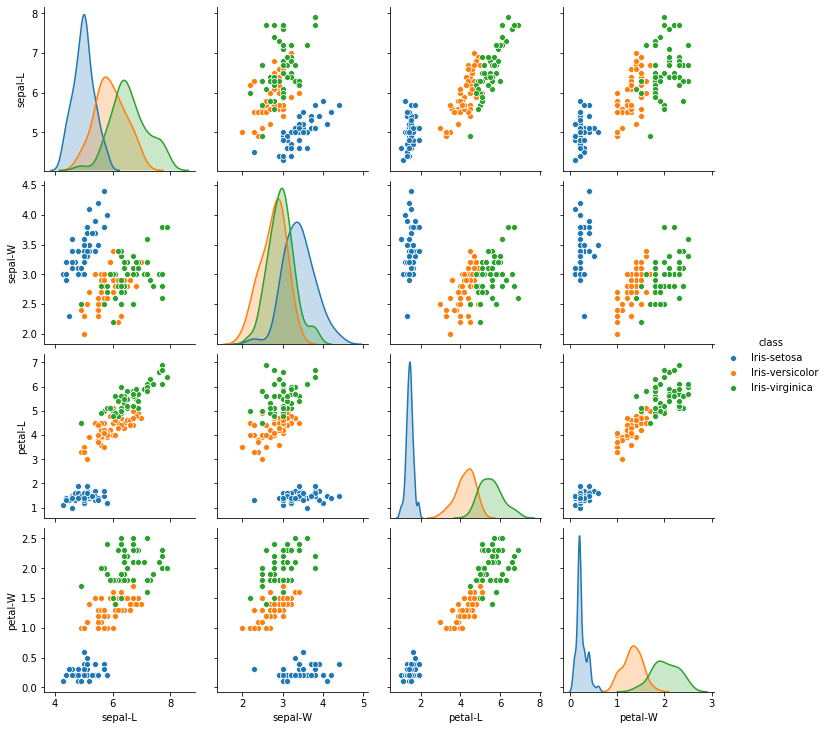

In [3]:
import seaborn as sns #let's take a look at the pairwise plot
sns.pairplot(iris, hue="class") #which features are most representative?

### 1.2 Identify your features and target

In [4]:
features=['sepal-L','sepal-W','petal-L','petal-W']
target=['class']
X=iris[features]
y=iris[target]
display(X)

,sepal-L,sepal-W,petal-L,petal-W
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 1.3 select the TWO most representative features from the 4 features using measurement Chi2. The *SelectKBest* is the algorithm you pick from the library.
The *chi2* is the measurement, you can change it to *f_classif* (ANOVA f-value).
The *k=2* is the number of optimal features you select from the complete set.

**<font color="red">Code:</font>**

In [5]:
X_new=SelectKBest(chi2, k=2).fit_transform(X,y) #we use chi2 as the criteria and select k=2 best features
X_new.shape # you get a new feature set of dimension k=2

(150, 2)

### 1.4 Check the selected features

In [6]:
display(X_new[0:5,:]) #petal-L and petal-W were selected

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

## 2. Feature Selection - use Wrapper model to measure feature importance


**<font color="red">Code:</font>** The following code identify the algorithm SelectFromModel from sklearn library. This is a kind of Wrapper model. The algorithm select for feature importance measurement is ExtraTreesClassifier.

In [7]:
from sklearn.ensemble import ExtraTreesClassifier
#This class implements a meta estimator that fits a number of randomized decision trees 
#(a.k.a. extra-trees) on various sub-samples of the dataset and 
#uses averaging to improve the predictive accuracy and control over-fitting.

from sklearn.feature_selection import SelectFromModel

### 2.1 We will generate the dataset

**<font color="red">Code:</font>**

In [8]:
iris = pd.read_csv('iris.txt',header=None)
iris.columns=['sepal-L','sepal-W','petal-L','petal-W','class']
features=['sepal-L','sepal-W','petal-L','petal-W']
target=['class']
X=iris[features]
y=iris[target]
X=X.values
y=y.values.ravel()  #please note y is a one-dimensional data, we need to use ravel() to reshape it to (n,) 

In [9]:
y.shape

(150,)

### 2.2 We identify a classifier and use the classifier to measure feature importance

In [10]:
clf = ExtraTreesClassifier(n_estimators=50) #get the model from library
clf = clf.fit(X,y) #fit your data
clf.feature_importances_ # now we can get the feature importance score from model

array([0.11489972, 0.05970171, 0.38326999, 0.44212858])

### 2.3 select your feature subset from SelectFromModel

reference: https://scikit-learn.org/stable/modules/feature_selection.html#select-from-model 

**<font color="red">Code:</font>**

In [11]:
selection = SelectFromModel(clf, prefit=True)
X_new=selection.transform(X)
display(X_new[0:5,:])

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

### 2.4 Recursive Feature Elimination (RFE)
Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through a coef_ attribute or through a feature_importances_ attribute. Then, the least important features are pruned from current set of features.That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached. 

In [12]:
from sklearn.feature_selection import RFE
clf = ExtraTreesClassifier(n_estimators=50)
selection = RFE(estimator=clf, n_features_to_select=2, step=1)
selection.fit(X,y)
X_new=selection.transform(X)
display(X_new[0:5,:])

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

In [13]:
#alternatively, put fit and transform together:
X_new=selection.fit_transform(X,y)
display(X_new[0:5,:])

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2]])

## 3. Feature Reduction - Principle Component Analysis (PCA)

Principal Component Analysis (PCA) applied to this data identifies the combination of attributes (principal components, or directions in the feature space) that account for the most variance in the data. Here we plot the different samples on the 2 first principal components.

**<font color="red">Code:</font>** we first get PCA algorithm from the library and then map the 4-dimensional feature set into a 2-dimensional feature set:

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

We map it to a two dimensional space

**<font color="red">Code:</font>**

In [15]:
iris = pd.read_csv('iris.txt',header=None)
iris.columns=['sepal-L','sepal-W','petal-L','petal-W','class']
features=['sepal-L','sepal-W','petal-L','petal-W']
X=iris[features]
X=X.values
pca = PCA(n_components=2) # we select PCA algorithm with 2 dimensions
z = pca.fit(X).transform(X)

In [16]:
display(z[:5,:])

array([[-2.68420713,  0.32660731],
       [-2.71539062, -0.16955685],
       [-2.88981954, -0.13734561],
       [-2.7464372 , -0.31112432],
       [-2.72859298,  0.33392456]])

In [17]:
iris['z1']=z[:,0]
iris['z2']=z[:,1]
iris.head()

,sepal-L,sepal-W,petal-L,petal-W,class,z1,z2
0,5.1,3.5,1.4,0.2,Iris-setosa,-2.684207,0.326607
1,4.9,3.0,1.4,0.2,Iris-setosa,-2.715391,-0.169557
2,4.7,3.2,1.3,0.2,Iris-setosa,-2.889820,-0.137346
3,4.6,3.1,1.5,0.2,Iris-setosa,-2.746437,-0.311124
4,5.0,3.6,1.4,0.2,Iris-setosa,-2.728593,0.333925


We scatter plot the data in a the new space of z

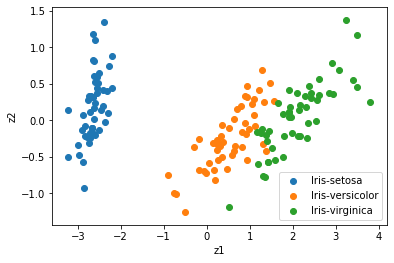

In [18]:
import matplotlib.pyplot as plt
groups = iris.groupby("class")
for name, group in groups:
    plt.scatter(group['z1'],group['z2'], marker="o", label=name)
plt.xlabel('z1')
plt.ylabel('z2')
plt.legend()
plt.show()

# Week 4 Assignment

## 1. use f_classif as your evaluation measurement and redo the feature selection in Univariate feature selection. what does "f_classif" represent? Is this a filter model or wrapper model? (10 points). 

## 2. Explain the differences among univariate feature selection, SelectFromModel method, and PCA. (10 points)

## 3. Read documentation of "SequentialFeatureSelector" and use it to select the top TWO features. What is the mechnism of this tool? What are these two optimal features? (40 points)

document: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html

## 4. Use the Airbnb.csv on Canvas-Week4 Homepage. Select the most representative 3 features from the dataset for price prediction. You may use any feature selection methods but please interpret your steps with codes (20 points).